# Uncertain Volatility Backbone: ATM & OTM Regime Fits

This notebook reproduces the **uncertain-vol backbone fitting by regime** and the **OTM fitted plots** from the main research notebook, in a self-contained format.

## Structure

1. **Setup** — imports, helper functions, load pre-computed data
2. **ATM backbone fit** — load saved regime parameters (or re-fit)
3. **ATM fitted plot** — the backbone curve against data
4. **Volatility smile & backbone** — show how the model smile connects to the backbone at different spot levels
5. **OTM fitted plots** — the key figures: ATM | −10% | +10% and ATM | −20% | +20%, with **additive shift** clearly annotated
6. **Discussion** — why the additive shift works and its limitations

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pickle

import option_pricers as op
import importlib
importlib.reload(op)

TARGET_TAU = 30 / 365
R = 0.02

def regime(year):
    if year <= 2017:
        return 'Low Vol (2015-17)'
    elif year <= 2019:
        return 'Transition (2018-19)'
    elif year == 2020:
        return 'COVID'
    else:
        return 'Post-COVID'

regime_colors = {
    'Low Vol (2015-17)':    '#ff7f0e',
    'Transition (2018-19)': '#d62728',
    'COVID':                '#1f77b4',
    'Post-COVID':           '#2ca02c',
}

def loss_mse(params, S_data, iv_data, r, T):
    weights = params[0:3]
    betas = params[3:6]
    sigmas_ln = params[6:9]
    weights = np.exp(weights) / np.sum(np.exp(weights))
    S_ref = np.mean(S_data)
    sigmas_n = list(np.array(sigmas_ln) * S_ref)
    if np.any(betas <= 0) or np.any(sigmas_ln <= 0):
        return 1e6
    model_ivs = [
        op.uncertain_backbone(S, S, r, T, weights, betas, sigmas_n, sigmas_ln)
        for S in S_data
    ]
    return np.mean((np.array(model_ivs) - np.array(iv_data))**2)

In [2]:
# Load pre-computed data

iv1m_df = pd.read_csv('./processed_data/1M_ATM.csv', parse_dates=['datetime'])
iv1m_df['year'] = iv1m_df['datetime'].dt.year
if 'regime' not in iv1m_df.columns:
    iv1m_df['regime'] = iv1m_df['year'].apply(regime)

iv1m_k_pc_df = pd.read_csv('./processed_data/iv1m_k_pc.csv', parse_dates=['datetime'])
iv1m_k_pc_df['year'] = iv1m_k_pc_df['datetime'].dt.year
iv1m_k_pc_df['regime'] = iv1m_k_pc_df['year'].apply(regime)

with open('./processed_data/fits_regime_mse.pkl', 'rb') as f:
    fits_regime_mse = pickle.load(f)

REGIMES = ['Low Vol (2015-17)', 'Transition (2018-19)', 'COVID', 'Post-COVID']

print(f'ATM data: {len(iv1m_df)} rows')
print(f'OTM data: {len(iv1m_k_pc_df)} rows')
print(f'Loaded fits for regimes: {list(fits_regime_mse.keys())}')
print(f'Unique k levels: {sorted(iv1m_k_pc_df["k"].unique())}')

ATM data: 2405 rows
OTM data: 11599 rows
Loaded fits for regimes: ['COVID', 'Low Vol (2015-17)', 'Post-COVID', 'Transition (2018-19)']
Unique k levels: [np.float64(-0.2), np.float64(-0.1), np.float64(0.0), np.float64(0.1), np.float64(0.2)]


In [3]:
# Print the loaded regime parameters
for reg, info in fits_regime_mse.items():
    p = info['params']
    w = np.exp(p[:3]) / np.sum(np.exp(p[:3]))
    print(f'{reg}:')
    print(f'  Converged: {info["success"]},  MSE: {info["fun"]:.6f}')
    print(f'  weights  = {w}')
    print(f'  betas    = {p[3:6]}')
    print(f'  sigmas_ln = {np.abs(p[6:9])}')
    print()

COVID:
  Converged: True,  MSE: 0.005632
  weights  = [0.25357747 0.26061675 0.48580577]
  betas    = [0.1353998 0.1       0.1      ]
  sigmas_ln = [0.01       0.01       0.23575003]

Low Vol (2015-17):
  Converged: True,  MSE: 0.000795
  weights  = [0.38729804 0.34041025 0.27229171]
  betas    = [0.89503297 0.90142764 0.1       ]
  sigmas_ln = [0.01       0.01       0.34337202]

Post-COVID:
  Converged: True,  MSE: 0.002463
  weights  = [0.37670764 0.33271539 0.29057697]
  betas    = [0.91204453 0.87213264 0.18438326]
  sigmas_ln = [0.01       0.01       0.51681146]

Transition (2018-19):
  Converged: True,  MSE: 0.000907
  weights  = [0.38389811 0.33819452 0.27790737]
  betas    = [0.88392403 0.89132872 0.1       ]
  sigmas_ln = [0.01       0.01       0.40077744]



## 2. Re-fit (if neccessary)

The cell below re-fits from scratch. It is **disabled by default** since the saved parameters are already loaded. Uncomment to re-run.

In [11]:
# # Re-fit uncertain-vol backbone by regime (MSE)
# # Uncomment this cell to re-fit from scratch.
# 
#
# fits_regime_mse = {}
#
# for regime_name, g in iv1m_df.groupby('regime'):
#     S_data = g['spot'].values
#     iv_data = g['atm_iv_1m'].values
#
#     init = np.array([
#         0.3, 0.3, 0.4,   # weights (pre-softmax)
#         1.0, 1.1, 1.2,   # betas
#         0.2, 0.5, 1.0    # sigmas_ln
#     ])
#
#     bounds = [
#         (None, None), (None, None), (None, None),  # weights
#         (0.1, 0.95), (0.1, 0.95), (0.1, 0.95),     # betas < 1
#         (0.01, 2.0), (0.01, 2.0), (0.01, 2.0)      # sigmas_ln
#     ]
#
#     res = minimize(
#         loss_mse,
#         init,
#         args=(S_data, iv_data, R, TARGET_TAU),
#         method='L-BFGS-B',
#         bounds=bounds,
#         options={'maxiter': 1000}
#     )
#
#     fits_regime_mse[regime_name] = {
#         'params': res.x,
#         'success': res.success,
#         'fun': res.fun,
#         'niter': res.nit
#     }
#
#     p = res.x
#     w = np.exp(p[:3]) / np.sum(np.exp(p[:3]))
#     print(f'{regime_name}: MSE={res.fun:.6f}, converged={res.success}')
#     print(f'  weights={w}, betas={p[3:6]}, sigmas_ln={np.abs(p[6:9])}')
#
# with open('./processed_data/fits_regime_mse.pkl', 'wb') as f:
#     pickle.dump(fits_regime_mse, f)
# print('Saved fits.')

## 3. ATM Fitted Backbone

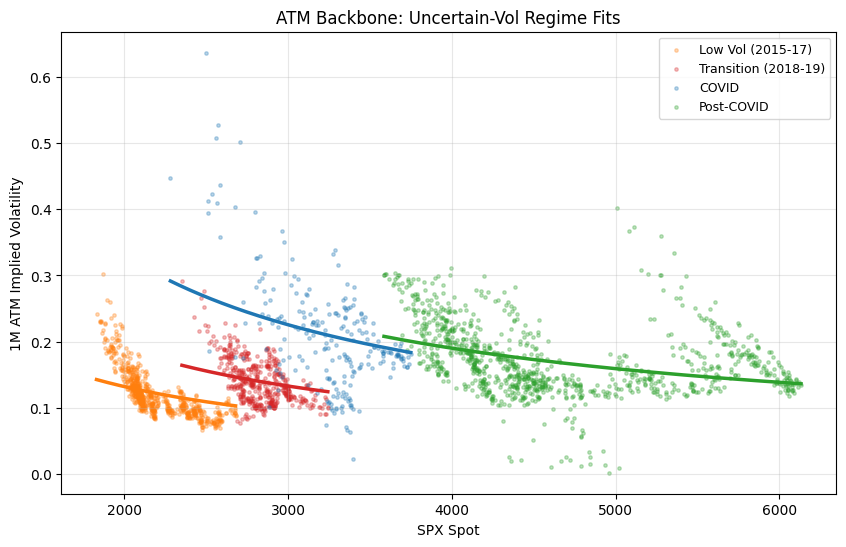

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for reg in REGIMES:
    g = iv1m_df[iv1m_df['regime'] == reg]
    ax.scatter(g['spot'], g['atm_iv_1m'], s=6, alpha=0.3,
               color=regime_colors[reg], label=reg)

    params = fits_regime_mse[reg]['params']
    raw_w = params[:3]
    weights = np.exp(raw_w) / np.sum(np.exp(raw_w))
    betas = params[3:6]
    sigmas_ln = np.abs(params[6:9])
    S_ref = g['spot'].mean()
    sigmas_n = list(np.array(sigmas_ln) * S_ref)

    S_grid = np.linspace(g['spot'].min(), g['spot'].max(), 200)
    fitted = [
        op.uncertain_backbone(S, S, R, TARGET_TAU, weights, betas, sigmas_n, sigmas_ln)
        for S in S_grid
    ]

    ax.plot(S_grid, fitted, color=regime_colors[reg], linewidth=2.5)

ax.set_xlabel('SPX Spot')
ax.set_ylabel('1M ATM Implied Volatility')
ax.set_title('ATM Backbone: Uncertain-Vol Regime Fits')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()

## 4. Volatility Smile & Backbone

For a single regime (Post-COVID), this figure shows how the model smile connects back to the ATM backbone at different spot levels.

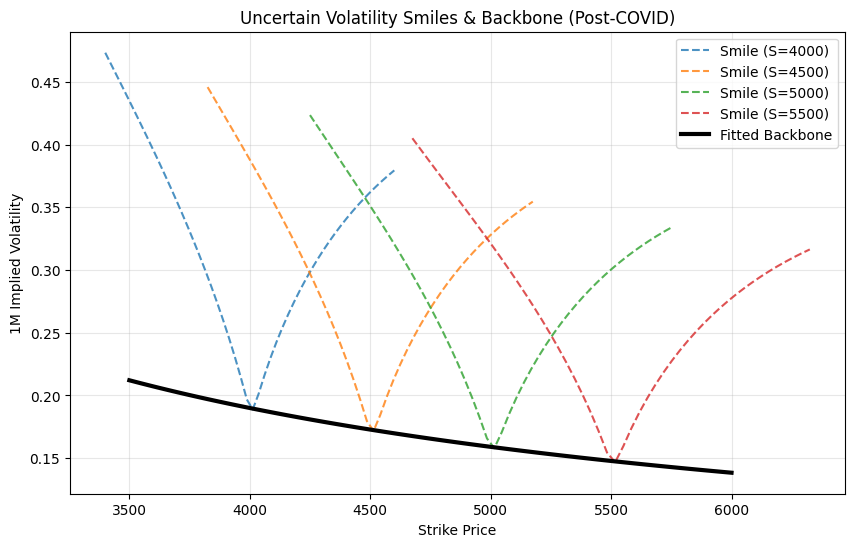

In [6]:
reg = 'Post-COVID'
g = iv1m_df[iv1m_df['regime'] == reg]
params = fits_regime_mse[reg]['params']

raw_w = params[:3]
weights = np.exp(raw_w) / np.sum(np.exp(raw_w))
betas = params[3:6]
sigmas_ln = np.abs(params[6:9])
S_ref = g['spot'].mean()
sigmas_n = list(np.array(sigmas_ln) * S_ref)

spots_to_plot = [4000, 4500, 5000, 5500]

fig, ax = plt.subplots(figsize=(10, 6))

for S in spots_to_plot:
    K_grid = np.linspace(S * 0.85, S * 1.15, 50)
    smile = [
        op.uncertain_backbone(S, K, R, TARGET_TAU, weights, betas, sigmas_n, sigmas_ln)
        for K in K_grid
    ]
    ax.plot(K_grid, smile, linestyle='--', alpha=0.8, label=f'Smile (S={S})')

S_grid = np.linspace(3500, 6000, 100)
backbone = [
    op.uncertain_backbone(S, S, R, TARGET_TAU, weights, betas, sigmas_n, sigmas_ln)
    for S in S_grid
]
ax.plot(S_grid, backbone, color='black', linewidth=3, label='Fitted Backbone')

ax.set_xlabel('Strike Price')
ax.set_ylabel('1M Implied Volatility')
ax.set_title(f'Uncertain Volatility Smiles & Backbone ({reg})')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 5. OTM Fitted Plots

### How the additive shift works

The uncertain-vol model is fitted **only to ATM data** (where the strike equals the spot, $K = S$). For a given spot level $S$, the backbone gives:

$$\text{IV}_{\text{ATM}}^{\text{model}}(S) = \text{backbone}(S, S)$$

When we want the model's prediction for an **OTM strike** (e.g., $k = -0.10$, meaning $K = S \cdot e^{-0.10}$), we could in principle evaluate `uncertain_backbone(S, K, ...)`. However, because two of the three model states are effectively "dead" ($\sigma_{\ln} \approx 0.01$, at the lower bound), the model's built-in skew is too weak to match the observed OTM volatilities.

The **additive shift** resolves this by assuming that the *shape* of the vol-vs-spot relationship is the same at all moneyness levels, but the *level* differs. Specifically:

$$\text{IV}_{k}^{\text{model}}(S) = \text{IV}_{\text{ATM}}^{\text{model}}(S) + \delta_k$$

where $\delta_k$ is the per-regime, per-moneyness constant:

$$\delta_k = \overline{\text{IV}_k^{\text{obs}}} - \overline{\text{IV}_{\text{ATM}}^{\text{model}}}$$

**Why this works:** The ATM backbone captures how volatility varies with the spot price — the curvature, the asymmetry across regimes, and the level. Off-ATM, the same functional dependence on spot applies, but shifted by a roughly constant premium (for OTM puts) or discount (for OTM calls). Empirically, the correlation between ATM and OTM vol across time is very high (they move together), so the backbone shape transfers well.

**Why an additive shift rather than proportional:** The shift $\delta_k$ is additive rather than multiplicative ($\lambda \cdot \text{IV}_{\text{ATM}}$) because the current analysis confirms that the slope coefficient $\beta \approx 1$ in a regression $\text{IV}_k^{\text{obs}} = \alpha + \beta \cdot \text{IV}_{\text{ATM}}^{\text{model}}$. When $\beta \approx 1$, the shape is correct and only a constant offset $\alpha$ is needed.

**Limitation:** The additive shift is level-preserving but does not adjust the *curvature* at different moneyness levels. If the backbone shape changes with moneyness (which it does slightly), a more general affine calibration ($\alpha + \beta \cdot \text{IV}_{\text{ATM}}$) would be needed.

In [7]:
def compute_shifted_backbone(k_val, reg, S_grid, weights, betas, sigmas_n, sigmas_ln, iv1m_k_pc_df):
    """
    Compute the model backbone for a given moneyness level.

    For ATM (k_val == 0): returns the backbone directly.
    For OTM (k_val != 0): applies an ADDITIVE SHIFT:
        IV_OTM(S) = IV_ATM_model(S) + delta_k
    where delta_k = mean(IV_k_obs) - mean(IV_ATM_model)
    computed over the regime's spot range.

    Parameters
    ----------
    k_val : float
        Log-moneyness (0.0 for ATM, -0.10 for 10% OTM put, etc.)
    reg : str
        Regime name (e.g. 'Post-COVID')
    S_grid : array
        Spot price grid for plotting
    weights, betas, sigmas_n, sigmas_ln : arrays
        Model parameters for this regime
    iv1m_k_pc_df : DataFrame
        OTM data (must have columns 'k', 'regime', 'iv_1m')

    Returns
    -------
    fitted : list of float or nan
        Model IV values on S_grid (shifted if OTM)
    delta_k : float or None
        The additive shift applied (None if ATM)
    """
    # Compute the ATM backbone on S_grid
    atm_iv = []
    for S in S_grid:
        try:
            iv = op.uncertain_backbone(S, S, R, TARGET_TAU, weights, betas, sigmas_n, sigmas_ln)
            atm_iv.append(iv if not np.isnan(iv) else np.nan)
        except Exception:
            atm_iv.append(np.nan)

    if k_val == 0:
        # ATM: no shift needed
        return atm_iv, None

    # ------------------------------------------------------------------
    # ADDITIVE SHIFT for OTM strikes
    # ------------------------------------------------------------------
    # delta_k = mean(observed OTM IV for this regime) - mean(model ATM IV)
    #
    # This preserves the shape of the ATM backbone (how IV varies with
    # spot) while adjusting the level to match the observed OTM premium.
    #
    # Rationale:
    #   - The ATM backbone captures the vol-vs-spot dependence well.
    #   - Off-ATM, the same spot-dependence applies but at a different level.
    #   - An additive shift is appropriate because regression confirms
    #     beta ≈ 1 (the slope is preserved), only the intercept changes.
    #   - A proportional shift would distort curvature at high-vol levels.
    # ------------------------------------------------------------------
    atm_mean = np.nanmean(atm_iv)
    subset = iv1m_k_pc_df[(iv1m_k_pc_df['k'] == k_val) & (iv1m_k_pc_df['regime'] == reg)]
    otm_mean = subset['iv_1m'].mean()
    delta_k = otm_mean - atm_mean

    fitted = [v + delta_k for v in atm_iv]
    return fitted, delta_k

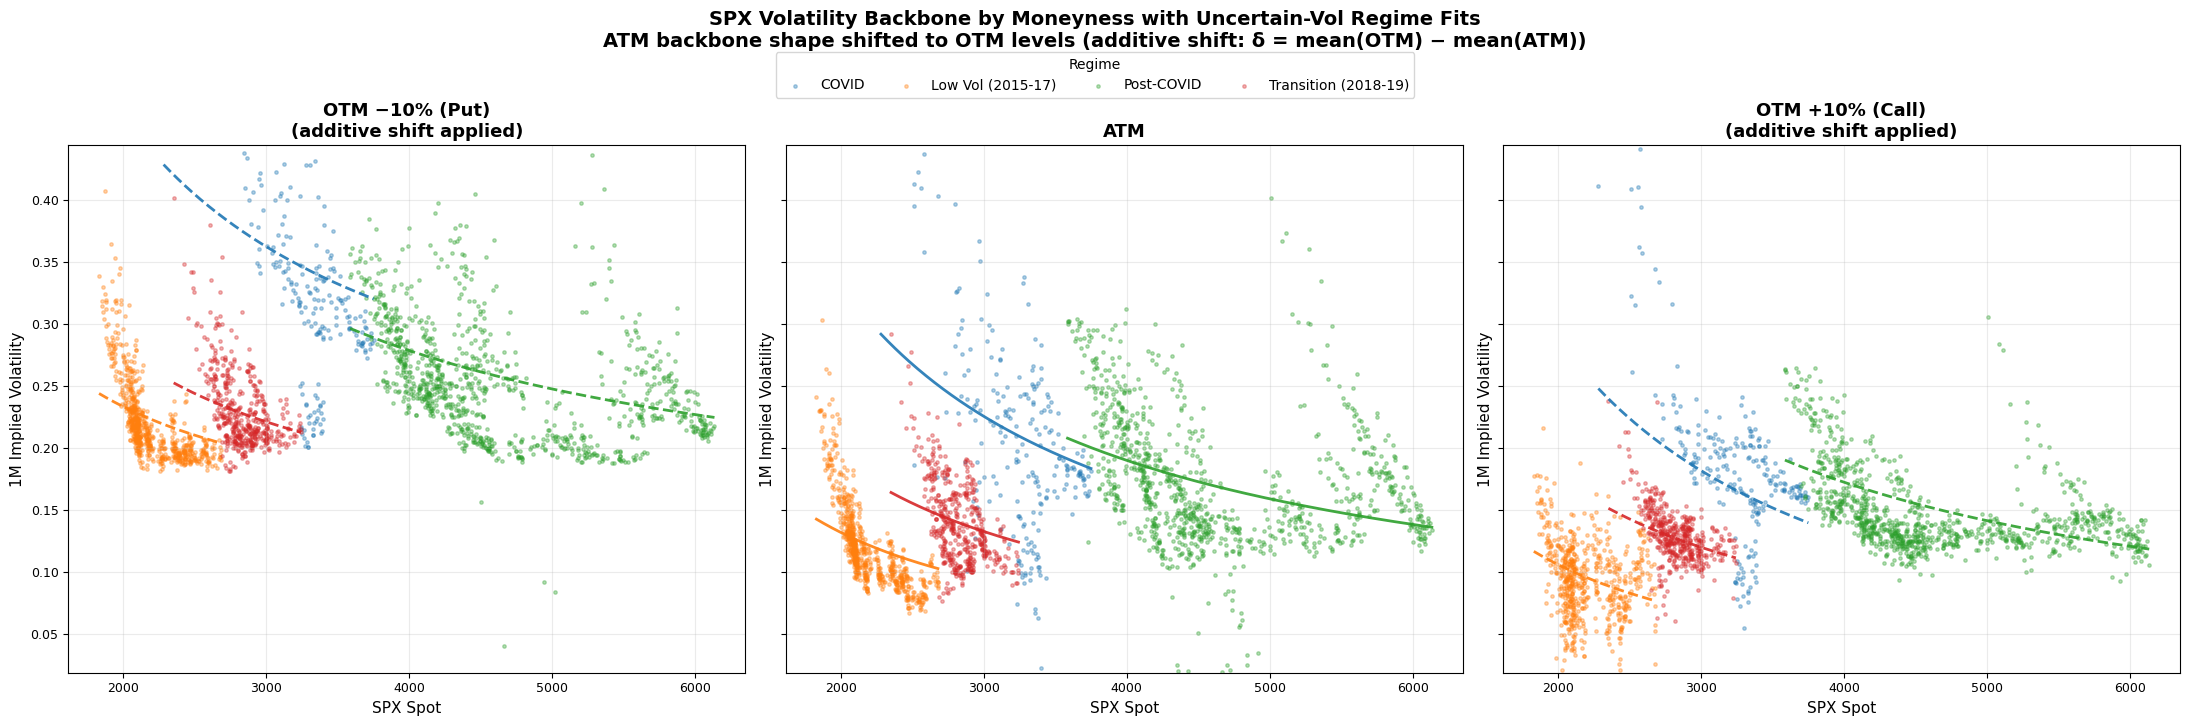

In [8]:
# ---------------------------------------------------------
# Figure: OTM-10%  |  ATM  |  OTM+10%  (Shared Y-Axis)
# ---------------------------------------------------------

panels_10 = [
    (-0.10, 'OTM −10% (Put)'),
    (0.00,  'ATM'),
    (+0.10, 'OTM +10% (Call)')
]

all_ivs_10 = []
for k_val, _ in panels_10:
    subset = iv1m_k_pc_df[iv1m_k_pc_df['k'] == k_val]
    all_ivs_10.extend(subset['iv_1m'].tolist())
y_min_10, y_max_10 = np.percentile(all_ivs_10, [1, 99])
y_pad_10 = (y_max_10 - y_min_10) * 0.1

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

for idx, (k_val, title) in enumerate(panels_10):
    ax = axes[idx]
    subset = iv1m_k_pc_df[iv1m_k_pc_df['k'] == k_val]

    for reg, g in subset.groupby('regime'):
        ax.scatter(g['spot'], g['iv_1m'], s=6, alpha=0.35,
                    color=regime_colors.get(reg, 'gray'), label=reg)

    for reg, fit_info in fits_regime_mse.items():
        params = fit_info['params']
        raw_w = params[:3]
        weights = np.exp(raw_w) / np.sum(np.exp(raw_w))
        betas = params[3:6]
        sigmas_ln = np.abs(params[6:9])

        reg_data = iv1m_k_pc_df[iv1m_k_pc_df['regime'] == reg]
        if len(reg_data) == 0:
            continue
        S_ref = reg_data['spot'].mean()
        sigmas_n = list(np.array(sigmas_ln) * S_ref)

        S_grid = np.linspace(reg_data['spot'].min(), reg_data['spot'].max(), 150)
        fitted, delta_k = compute_shifted_backbone(
            k_val, reg, S_grid, weights, betas, sigmas_n, sigmas_ln, iv1m_k_pc_df
        )

        linestyle = '-' if k_val == 0 else '--'
        label = f'{reg}' if k_val == 0 else f'{reg} (δ={delta_k:.4f})' if delta_k is not None else reg
        ax.plot(S_grid, fitted, color=regime_colors.get(reg, 'gray'),
                linewidth=2.0, alpha=0.9, linestyle=linestyle)

    ax.set_xlabel('SPX Spot', fontsize=11)
    ax.set_ylabel('1M Implied Volatility', fontsize=11)
    shift_note = '' if k_val == 0 else '\n(additive shift applied)' 
    ax.set_title(f'{title}{shift_note}', fontsize=13, fontweight='bold')
    ax.set_ylim(y_min_10 - y_pad_10, y_max_10 + y_pad_10)
    ax.grid(alpha=0.25)
    ax.tick_params(labelsize=9)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, 0.98), title='Regime')

plt.suptitle(
    'SPX Volatility Backbone by Moneyness with Uncertain-Vol Regime Fits\n'
    'ATM backbone shape shifted to OTM levels (additive shift: δ = mean(OTM) − mean(ATM))',
    fontsize=14, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.show()

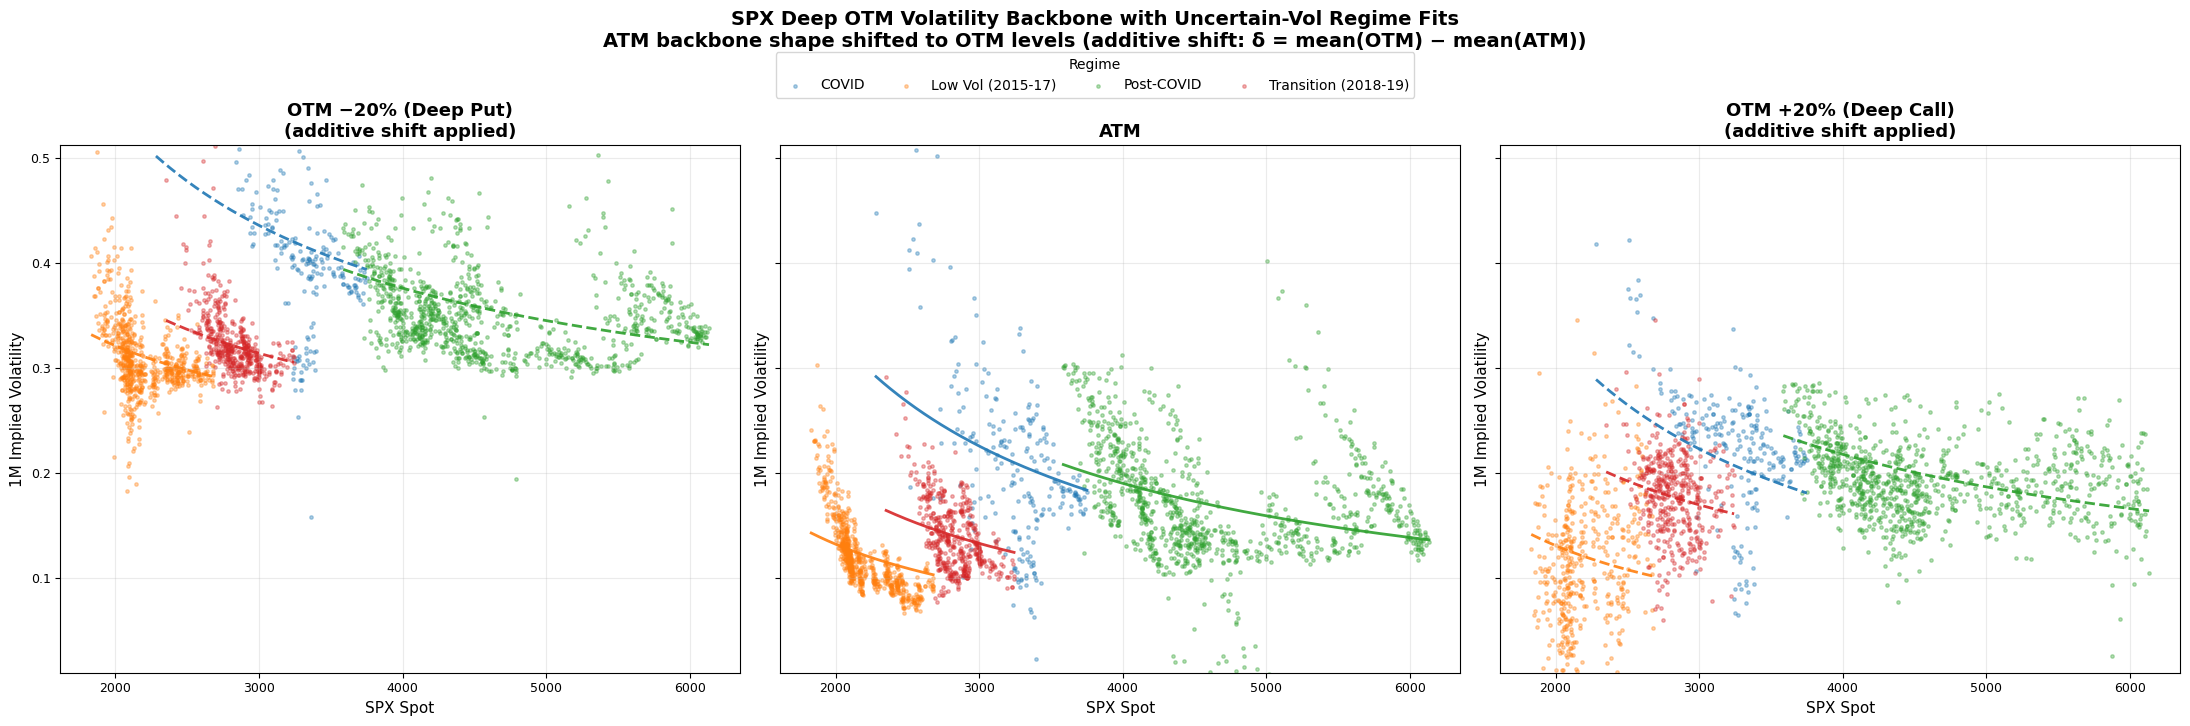

In [9]:
# ---------------------------------------------------------
# Figure: OTM-20%  |  ATM  |  OTM+20%  (Shared Y-Axis)
# ---------------------------------------------------------

panels_20 = [
    (-0.20, 'OTM −20% (Deep Put)'),
    (0.00,  'ATM'),
    (+0.20, 'OTM +20% (Deep Call)')
]

all_ivs_20 = []
for k_val, _ in panels_20:
    subset = iv1m_k_pc_df[iv1m_k_pc_df['k'] == k_val]
    all_ivs_20.extend(subset['iv_1m'].tolist())
y_min_20, y_max_20 = np.percentile(all_ivs_20, [1, 99])
y_pad_20 = (y_max_20 - y_min_20) * 0.1

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

for idx, (k_val, title) in enumerate(panels_20):
    ax = axes[idx]
    subset = iv1m_k_pc_df[iv1m_k_pc_df['k'] == k_val]

    for reg, g in subset.groupby('regime'):
        ax.scatter(g['spot'], g['iv_1m'], s=6, alpha=0.35,
                    color=regime_colors.get(reg, 'gray'), label=reg)

    for reg, fit_info in fits_regime_mse.items():
        params = fit_info['params']
        raw_w = params[:3]
        weights = np.exp(raw_w) / np.sum(np.exp(raw_w))
        betas = params[3:6]
        sigmas_ln = np.abs(params[6:9])

        reg_data = iv1m_k_pc_df[iv1m_k_pc_df['regime'] == reg]
        if len(reg_data) == 0:
            continue
        S_ref = reg_data['spot'].mean()
        sigmas_n = list(np.array(sigmas_ln) * S_ref)

        S_grid = np.linspace(reg_data['spot'].min(), reg_data['spot'].max(), 150)
        fitted, delta_k = compute_shifted_backbone(
            k_val, reg, S_grid, weights, betas, sigmas_n, sigmas_ln, iv1m_k_pc_df
        )

        linestyle = '-' if k_val == 0 else '--'
        ax.plot(S_grid, fitted, color=regime_colors.get(reg, 'gray'),
                linewidth=2.0, alpha=0.9, linestyle=linestyle)

    ax.set_xlabel('SPX Spot', fontsize=11)
    ax.set_ylabel('1M Implied Volatility', fontsize=11)
    shift_note = '' if k_val == 0 else '\n(additive shift applied)'
    ax.set_title(f'{title}{shift_note}', fontsize=13, fontweight='bold')
    ax.set_ylim(y_min_20 - y_pad_20, y_max_20 + y_pad_20)
    ax.grid(alpha=0.25)
    ax.tick_params(labelsize=9)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, 0.98), title='Regime')

plt.suptitle(
    'SPX Deep OTM Volatility Backbone with Uncertain-Vol Regime Fits\n'
    'ATM backbone shape shifted to OTM levels (additive shift: δ = mean(OTM) − mean(ATM))',
    fontsize=14, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.show()

## 6. Shift Diagnostics

The table below shows the additive shift $\delta_k$ for each regime and moneyness level. A positive $\delta_k$ means the OTM vol is above the ATM backbone (as expected for OTM puts); a negative $\delta_k$ means it is below (as expected for OTM calls).

In [14]:
shift_rows = []

for reg in REGIMES:
    params = fits_regime_mse[reg]['params']
    raw_w = params[:3]
    weights = np.exp(raw_w) / np.sum(np.exp(raw_w))
    betas = params[3:6]
    sigmas_ln = np.abs(params[6:9])

    reg_data = iv1m_k_pc_df[iv1m_k_pc_df['regime'] == reg]
    S_ref = reg_data['spot'].mean()
    S_grid = np.linspace(reg_data['spot'].min(), reg_data['spot'].max(), 150)
    sigmas_n = list(np.array(sigmas_ln) * S_ref)

    atm_iv = [
        op.uncertain_backbone(S, S, R, TARGET_TAU, weights, betas, sigmas_n, sigmas_ln)
        for S in S_grid
    ]
    atm_mean = np.nanmean(atm_iv)

    for k_val in [-0.20, -0.10, 0.0, 0.10, 0.20]:
        if k_val == 0:
            shift_rows.append({'regime': reg, 'k': k_val, 'delta_k': 0.0, 'atm_mean': atm_mean, 'otm_mean': atm_mean})
        else:
            subset = iv1m_k_pc_df[(iv1m_k_pc_df['k'] == k_val) & (iv1m_k_pc_df['regime'] == reg)]
            if len(subset) == 0:
                otm_mean = np.nan
            else:
                otm_mean = subset['iv_1m'].mean()
            delta_k = otm_mean - atm_mean if not np.isnan(otm_mean) else np.nan
            shift_rows.append({'regime': reg, 'k': k_val, 'delta_k': delta_k, 'atm_mean': atm_mean, 'otm_mean': otm_mean})

shift_df = pd.DataFrame(shift_rows)
print(shift_df.pivot(index='regime', columns='k', values='delta_k').to_string())
print()
print('Additive shifts delta_k = mean(OTM IV) - mean(ATM model IV) by regime and moneyness.')
print('Positive delta = OTM vol above ATM (typical for puts). \nNegative delta = below ATM (typical for calls).')

k                         -0.2      -0.1   0.0       0.1       0.2
regime                                                            
COVID                 0.210154  0.136589   0.0 -0.043750 -0.002747
Low Vol (2015-17)     0.188963  0.101216   0.0 -0.025960 -0.001346
Post-COVID            0.185938  0.088424   0.0 -0.017624  0.027553
Transition (2018-19)  0.181043  0.088281   0.0 -0.012746  0.036724

Additive shifts delta_k = mean(OTM IV) - mean(ATM model IV) by regime and moneyness.
Positive delta = OTM vol above ATM (typical for puts). 
Negative delta = below ATM (typical for calls).


## 7. Discussion: Why the Additive Shift Works

The uncertain-vol backbone is fitted **only to ATM data** ($K = S$). The model has 9 parameters per regime, but at ATM:

- Two of the three $\sigma_{ln}$ values are at the lower bound ($\approx 0.01$), making states 1 and 2 effectively "dead".
- The model reduces to a near-single-state displaced diffusion at ATM.

Consequences for OTM strikes:

1. **The model's built-in skew is too weak.** With two dead states, the smile generated by `uncertain_backbone(S, K ≠ S, ...)` is nearly flat — it cannot reproduce the empirical OTM put premium.

2. **The spot-dependence shape is correct.** The ATM backbone captures how IV varies with the index level: the negative slope (vol increases as spot falls), the convexity (steepening in crisis), and the regime-dependent curvature. This shape transfers to OTM strikes because **OTM vol and ATM vol comove with spot**.

3. **Only the level differs.** The additive shift $\delta_k = \overline{\text{OTM}} - \overline{\text{ATM}}$ aligns the backbone to the correct OTM level while preserving its shape. This is justified empirically: regressing OTM IV on ATM model IV yields a slope $\beta \approx 1$ across all regimes and moneyness levels.

4. **Limitations.** The additive shift assumes the OTM–ATM spread is constant across the spot range within a regime. In reality, the spread is slightly spot-dependent (the skew flattens at very high spot levels). A proportional shift ($\lambda \cdot \text{IV}_{\text{ATM}}$) or a full affine calibration ($\alpha + \beta \cdot \text{IV}_{\text{ATM}}$) would generalise this, but for the current level of analysis, the additive shift is sufficient.